# Rollover anticline

Where bends in the faults are curved rather than straight, we can use inclined simple shear to simulate similar folds over the ramps. Hanging-wall rollover anticlines above listric normal faults represent the most common application.

In the figure below from [Allmendinger et al. (2012)](https://www.cambridge.org/core/books/structural-geology-algorithms/C5AB97C135925A5D49726B741738DCA9), we define a coordinate system with $\mathbf{x_1}$ horizontal and $\mathbf{x_2}$ vertical and specify $\alpha$, the angle between the vertical and the direction of inclined shear.

<img src="../figures/rollover.png" alt="rollover" width="750" style="display: block; margin: 0 auto"/><br><br>

The direction of inclined shear fixes the orientation of the $\mathbf{x_2'}$ axis of a second coordinate system, with $\mathbf{x_1'}$ perpendicular to it. The velocity perpendicular to the shearing, $v'_1$ is assumed to be constant and given by:

$$v'_1 = s\cos\alpha\quad(1)$$

where $s$ is the incremental slip. The velocity parallel to the shearing, $v'_2$ is given by:

$$v_2^{\prime}=\frac{s\left[\cos \alpha \sin \alpha+\left(\frac{\partial f}{\partial x_1}\right) \cos ^2 \alpha\right]}{\cos \alpha-\frac{\partial \mathrm{f}}{\partial x_1} \sin \alpha}\quad(2)$$

where $\frac{\partial f}{\partial x_1} = \tan\delta$, and $\delta$ is the fault dip at a position directly down the shear plane from the point of interest.

Points are transformed from the $\mathbf{x_1}$-$\mathbf{x_2}$ to the $\mathbf{x'_1}$-$\mathbf{x'_2}$ coordinate system, moved according to Eqs. 1 and 2, and transformed back to the $\mathbf{x_1}$-$\mathbf{x_2}$ coordinate system.

The function [similar_fold](../functions/similar_fold.py) plots the evolution of a similar fold. Let's start by simulating a rollover over a listric fault, formed by vertical shear ($\alpha=0^{\circ}$), which means vertical shear planes. In addition, we add growth strata ($G=0.0$) to fill in the space available from normal faulting, up to the top of the pre-growth strata.

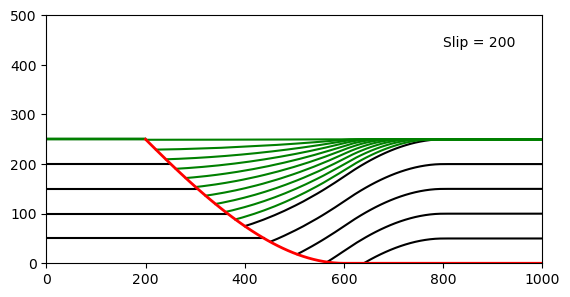

In [1]:
import numpy as np

# import our function
import sys, os
sys.path.append(os.path.abspath(os.path.join("..", "functions")))
from similar_fold import listric_fault, similar_fold

# listric fault defined by upper and lower points, 
# number of points, and x end of flat part
fault = listric_fault((200, 250, np.radians(45)),   # upper point at x=200, y=250, 45° dip
                      (600,   0, np.radians(0)),     # lower point at x=600 and y=0, horizontal
                      npts=40, x_end=1000)           # 40 points, extend flat to x=1000

# parameters for the similar fold
yp = [50, 100, 150, 200, 250] # datums of undeformed beds
psect = [1000, 500] # extent and number of points in each bed
alpha = np.radians(0) # angle of shear = 0; vertical shear
pslip = [200,1] # total and incremental slip on the fault
G = 0.0 # regional subsidence is zero

similar_fold(yp, psect, fault, alpha, pslip, G)

Let's use now $\alpha=30^{\circ}$, which means shear planes dipping 60° to the left, with shear antithetic to the fault:

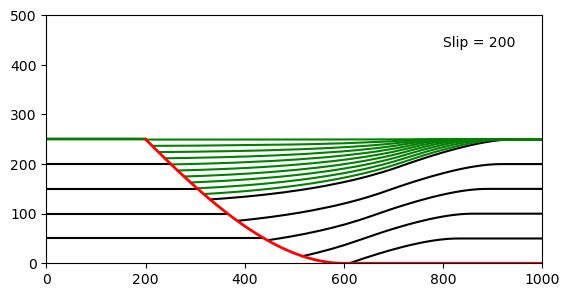

In [2]:
alpha = np.radians(30) # angle of shear = 30 degrees
similar_fold(yp, psect, fault, alpha, pslip, G)

And finally, $\alpha=-30^{\circ}$, which means shear planes dipping 60° to the right, with shear synthetic to the fault:

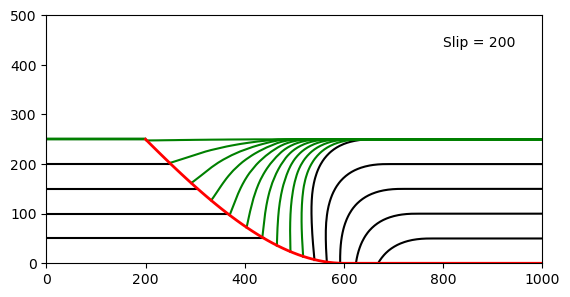

In [3]:
alpha = np.radians(-30) # angle of shear = -30 degrees
similar_fold(yp, psect, fault, alpha, pslip, G)

You can now experiment with any kind of fault geometry (not just with those produced by the [listric_fault](../functions/similar_fold.py) function), and different shear angles.